# E-Commerce Big Data Analytics with PySpark

This notebook implements the Spark components of the big data project:
- **Part 2** — Batch processing, data cleaning, Spark SQL, and cohort analysis
- **Part 3** — Customer Lifetime Value (CLV) estimation, integrating users, transactions, and sessions data
- **Part 4** — Visualisations of the analytical results

Datasets used: `users.json`, `products.json`, `transactions.json`, `sessions_*.json`.

## 1. Loading the Data

In [65]:
# Start a Spark session — this is the entry point for all DataFrame and SQL operations
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("EcommerceAnalytics").getOrCreate()
print(spark.version)

3.5.0


In [66]:
# Inspect the raw file as plain text first — this revealed that the source JSON
# is a single JSON array spanning the whole file, not newline-delimited JSON Lines.
# Spark's default reader assumes JSON Lines, so a plain spark.read.json() call
# fails here with a _corrupt_record error unless multiLine is set (see below).
spark.read.text("/home/jovyan/data/users.json").show(5, truncate=False)

+--------------------------------------------------------------------------------+
|value                                                                           |
+--------------------------------------------------------------------------------+
|[                                                                               |
|  {                                                                             |
|    "user_id": "user_000000",                                                   |
|    "geo_data": { "city": "North Douglasfurt", "state": "UT", "country": "UA" },|
|    "registration_date": "2025-12-08T15:56:48.465484",                          |
+--------------------------------------------------------------------------------+
only showing top 5 rows



In [67]:
# Load users.json with multiLine=True to correctly parse the JSON-array format
users_df = spark.read.option("multiLine", True).json("/home/jovyan/data/users.json")
users_df.show(5)

+--------------------+--------------------+--------------------+-----------+
|            geo_data|         last_active|   registration_date|    user_id|
+--------------------+--------------------+--------------------+-----------+
|{North Douglasfur...|2026-06-13T12:38:...|2025-12-08T15:56:...|user_000000|
|{North Michael, L...|2026-02-28T14:47:...|2026-02-01T06:31:...|user_000001|
|{Martinezchester,...|2026-03-24T15:00:...|2026-02-19T17:44:...|user_000002|
|{Katelynfurt, PY,...|2026-05-01T15:00:...|2026-01-27T05:49:...|user_000003|
| {Dixonberg, PH, WI}|2026-03-21T12:45:...|2026-03-10T20:08:...|user_000004|
+--------------------+--------------------+--------------------+-----------+
only showing top 5 rows



In [68]:
# Inspect the inferred schema — note registration_date/last_active are inferred
# as plain strings, not timestamps, since Spark does not parse date-like strings
# automatically. geo_data is correctly inferred as a nested struct.
users_df.printSchema()

root
 |-- geo_data: struct (nullable = true)
 |    |-- city: string (nullable = true)
 |    |-- country: string (nullable = true)
 |    |-- state: string (nullable = true)
 |-- last_active: string (nullable = true)
 |-- registration_date: string (nullable = true)
 |-- user_id: string (nullable = true)



In [69]:
# toPandas() pulls the full result to the driver and renders nested structs as
# readable dicts — fine here since the result is small, but should be avoided
# on large DataFrames since it collects everything into local memory.
users_df.toPandas().head()

,geo_data,last_active,registration_date,user_id
0,"(North Douglasfurt, UA, UT)",2026-06-13T12:38:20.558392,2025-12-08T15:56:48.465484,user_000000
1,"(North Michael, LU, ID)",2026-02-28T14:47:15.141767,2026-02-01T06:31:17.945826,user_000001
2,"(Martinezchester, SB, VA)",2026-03-24T15:00:18.658566,2026-02-19T17:44:31.799722,user_000002
3,"(Katelynfurt, PY, MI)",2026-05-01T15:00:03.184697,2026-01-27T05:49:40.692068,user_000003
4,"(Dixonberg, PH, WI)",2026-03-21T12:45:52.300437,2026-03-10T20:08:03.893814,user_000004


### Products

In [70]:
# Load products.json the same way — every JSON file in this project needs multiLine=True
products_df = spark.read.option("multiLine", True).json("/home/jovyan/data/products.json")
products_df.show(5)

+----------+-----------+--------------------+-------------+---------+--------------------+--------------------+----------+
|base_price|category_id|       creation_date|current_stock|is_active|                name|       price_history|product_id|
+----------+-----------+--------------------+-------------+---------+--------------------+--------------------+----------+
|     371.3|    cat_016|2025-12-26T02:47:...|          851|     true|Vision-Oriented N...|[{2025-12-26T02:4...|prod_00000|
|    123.53|    cat_009|2026-01-18T00:41:...|          750|     true|User-Friendly Coh...|[{2026-01-18T00:4...|prod_00001|
|     53.39|    cat_002|2026-01-14T18:03:...|          662|     true|Enhanced Incremen...|[{2026-01-14T18:0...|prod_00002|
|      80.8|    cat_004|2025-12-25T04:40:...|           44|     true|Open-Source Stati...|[{2025-12-25T04:4...|prod_00003|
|    214.45|    cat_019|2026-01-13T03:16:...|          815|     true|Future-Proofed Co...|[{2026-01-13T03:1...|prod_00004|
+----------+----

In [71]:
products_df.printSchema()

root
 |-- base_price: double (nullable = true)
 |-- category_id: string (nullable = true)
 |-- creation_date: string (nullable = true)
 |-- current_stock: long (nullable = true)
 |-- is_active: boolean (nullable = true)
 |-- name: string (nullable = true)
 |-- price_history: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- date: string (nullable = true)
 |    |    |-- price: double (nullable = true)
 |-- product_id: string (nullable = true)



In [72]:
# Count how many products are currently active
products_df.filter(products_df.is_active == True).count()

1435

## 2. Working with DataFrames

In [73]:
# col() lets us reference columns (including nested fields via dot notation)
from pyspark.sql.functions import col

# select() can reach into a nested struct directly using dot notation —
# no separate flattening step needed for struct fields (only arrays need explode())
users_df.select("user_id", "geo_data.city", "geo_data.country").show(5)

+-----------+-----------------+-------+
|    user_id|             city|country|
+-----------+-----------------+-------+
|user_000000|North Douglasfurt|     UA|
|user_000001|    North Michael|     LU|
|user_000002|  Martinezchester|     SB|
|user_000003|      Katelynfurt|     PY|
|user_000004|        Dixonberg|     PH|
+-----------+-----------------+-------+
only showing top 5 rows



In [74]:
# filter() using dot-notation column references (col_name.nested_field)
users_df.filter(col("geo_data.country") == "UA").show(5)

+--------------------+--------------------+--------------------+-----------+
|            geo_data|         last_active|   registration_date|    user_id|
+--------------------+--------------------+--------------------+-----------+
|{North Douglasfur...|2026-06-13T12:38:...|2025-12-08T15:56:...|user_000000|
|{East Jimmy, UA, ME}|2025-10-23T01:06:...|2025-09-30T23:23:...|user_000017|
|{East David, UA, HI}|2026-03-03T15:10:...|2025-10-25T10:59:...|user_000282|
| {Hillville, UA, WY}|2025-12-11T20:47:...|2025-10-31T07:15:...|user_000347|
|{South Blakeport,...|2026-02-27T07:59:...|2026-02-11T18:36:...|user_000583|
+--------------------+--------------------+--------------------+-----------+
only showing top 5 rows



In [75]:
users_df.filter(col("geo_data.country") == "UA").count()

14

In [76]:
# withColumn() adds a derived column without mutating the original DataFrame
# (DataFrames are immutable — every transformation returns a new DataFrame)
users_df.withColumn("reg_year", users_df.registration_date.substr(1, 4)) \
    .select("user_id", "registration_date", "reg_year").show(5)

+-----------+--------------------+--------+
|    user_id|   registration_date|reg_year|
+-----------+--------------------+--------+
|user_000000|2025-12-08T15:56:...|    2025|
|user_000001|2026-02-01T06:31:...|    2026|
|user_000002|2026-02-19T17:44:...|    2026|
|user_000003|2026-01-27T05:49:...|    2026|
|user_000004|2026-03-10T20:08:...|    2026|
+-----------+--------------------+--------+
only showing top 5 rows



In [77]:
# dropDuplicates() only compares the columns present at call time — here, after
# select(), the only column is "country", so this returns the distinct country list
users_df.select("geo_data.country").dropDuplicates().count()

195

In [78]:
# Without select() first, dropDuplicates() compares ALL columns — since every
# user_id is unique, no two full rows are identical, so the row count is unchanged
users_df.dropDuplicates().count()

2000

In [79]:
# orderBy() sorts ascending by default
users_df.orderBy("registration_date").select("user_id", "registration_date").show(5)

+-----------+--------------------+
|    user_id|   registration_date|
+-----------+--------------------+
|user_001898|2025-09-21T00:40:...|
|user_001338|2025-09-21T08:44:...|
|user_000704|2025-09-21T09:20:...|
|user_000833|2025-09-21T09:57:...|
|user_001032|2025-09-21T10:18:...|
+-----------+--------------------+
only showing top 5 rows



In [80]:
# Load transactions.json
transactions_df = spark.read.option("multiLine", True).json("/home/jovyan/data/transactions.json")
transactions_df.printSchema()

root
 |-- discount: double (nullable = true)
 |-- items: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- product_id: string (nullable = true)
 |    |    |-- quantity: long (nullable = true)
 |    |    |-- subtotal: double (nullable = true)
 |    |    |-- unit_price: double (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- session_id: string (nullable = true)
 |-- status: string (nullable = true)
 |-- subtotal: double (nullable = true)
 |-- timestamp: string (nullable = true)
 |-- total: double (nullable = true)
 |-- transaction_id: string (nullable = true)
 |-- user_id: string (nullable = true)



In [81]:
transactions_df.select("user_id", "total", "payment_method", "status").show(5)

+-----------+-------+--------------+---------+
|    user_id|  total|payment_method|   status|
+-----------+-------+--------------+---------+
|user_000862|   20.4|   credit_card|completed|
|user_001616| 543.57|     apple_pay|completed|
|user_000765|1575.07|        paypal|completed|
|user_000858|1062.98|        paypal|completed|
|user_000009| 418.86|     gift_card|completed|
+-----------+-------+--------------+---------+
only showing top 5 rows



In [82]:
# Filter for completed transactions over $100 — both conditions wrapped in
# parentheses, since Python's operator precedence requires this when using & with
# PySpark Column comparisons (without parens, & binds tighter than == and errors)
transactions_df.select("user_id", "total", "payment_method", "status") \
    .filter((transactions_df.status == "completed") & (transactions_df.total > 100)) \
    .show(5)

+-----------+-------+--------------+---------+
|    user_id|  total|payment_method|   status|
+-----------+-------+--------------+---------+
|user_001616| 543.57|     apple_pay|completed|
|user_000765|1575.07|        paypal|completed|
|user_000858|1062.98|        paypal|completed|
|user_000009| 418.86|     gift_card|completed|
|user_000029|1422.81|   credit_card|completed|
+-----------+-------+--------------+---------+
only showing top 5 rows



## 3. Cleaning and Normalising the Data

In [83]:
# to_timestamp() parses the string timestamp into a real timestamp type.
# truncate=False shows the full value: note the "T" separator and microseconds
# in the raw string disappear once parsed into a genuine timestamp type.
from pyspark.sql.functions import to_timestamp

transactions_df.select("transaction_id", "timestamp").withColumn(
    "timestamp_parsed", to_timestamp("timestamp")
).show(5, truncate=False)

+----------------+--------------------------+--------------------------+
|transaction_id  |timestamp                 |timestamp_parsed          |
+----------------+--------------------------+--------------------------+
|txn_1eaf3e7c0c4f|2026-05-25T04:23:05.197980|2026-05-25 04:23:05.19798 |
|txn_d7ec82b629a1|2026-05-06T08:50:16.294573|2026-05-06 08:50:16.294573|
|txn_c88239dcf4c5|2026-05-26T20:03:33.256959|2026-05-26 20:03:33.256959|
|txn_d93921d35762|2026-05-28T03:55:42.535767|2026-05-28 03:55:42.535767|
|txn_7eb65ae5ddeb|2026-05-21T22:45:52.700917|2026-05-21 22:45:52.700917|
+----------------+--------------------------+--------------------------+
only showing top 5 rows



In [84]:
# Confirm the type change in the schema: timestamp_parsed is now a true timestamp
transactions_df.select("transaction_id", "timestamp").withColumn(
    "timestamp_parsed", to_timestamp("timestamp")
).printSchema()

root
 |-- transaction_id: string (nullable = true)
 |-- timestamp: string (nullable = true)
 |-- timestamp_parsed: timestamp (nullable = true)



In [85]:
# items is an array of structs — one transaction can have multiple line items
transactions_df.select("transaction_id", "items").show(5, truncate=False)

+----------------+--------------------------------------------------------------------------------------------------+
|transaction_id  |items                                                                                             |
+----------------+--------------------------------------------------------------------------------------------------+
|txn_1eaf3e7c0c4f|[{prod_00117, 3, 20.4, 6.8}]                                                                      |
|txn_d7ec82b629a1|[{prod_00819, 1, 223.65, 223.65}, {prod_00737, 1, 319.92, 319.92}]                                |
|txn_c88239dcf4c5|[{prod_00766, 1, 126.88, 126.88}, {prod_00172, 3, 1433.22, 477.74}, {prod_01321, 1, 97.87, 97.87}]|
|txn_d93921d35762|[{prod_00351, 3, 544.83, 181.61}, {prod_00407, 2, 574.1, 287.05}]                                 |
|txn_7eb65ae5ddeb|[{prod_00099, 1, 48.43, 48.43}, {prod_00772, 2, 169.82, 84.91}, {prod_00413, 1, 222.66, 222.66}]  |
+----------------+--------------------------------------

In [86]:
# explode() turns the items array into multiple rows, one per line item.
# Note transaction_id is duplicated across each item belonging to the same transaction.
from pyspark.sql.functions import explode

transactions_df.select("transaction_id", explode("items").alias("item")).show(5, truncate=False)

+----------------+--------------------------------+
|transaction_id  |item                            |
+----------------+--------------------------------+
|txn_1eaf3e7c0c4f|{prod_00117, 3, 20.4, 6.8}      |
|txn_d7ec82b629a1|{prod_00819, 1, 223.65, 223.65} |
|txn_d7ec82b629a1|{prod_00737, 1, 319.92, 319.92} |
|txn_c88239dcf4c5|{prod_00766, 1, 126.88, 126.88} |
|txn_c88239dcf4c5|{prod_00172, 3, 1433.22, 477.74}|
+----------------+--------------------------------+
only showing top 5 rows



In [87]:
# item.* expands every field of the exploded struct into its own top-level column
transactions_df.select(
    "transaction_id",
    explode("items").alias("item")
).select(
    "transaction_id",
    "item.*"
).show(5, truncate=False)

+----------------+----------+--------+--------+----------+
|transaction_id  |product_id|quantity|subtotal|unit_price|
+----------------+----------+--------+--------+----------+
|txn_1eaf3e7c0c4f|prod_00117|3       |20.4    |6.8       |
|txn_d7ec82b629a1|prod_00819|1       |223.65  |223.65    |
|txn_d7ec82b629a1|prod_00737|1       |319.92  |319.92    |
|txn_c88239dcf4c5|prod_00766|1       |126.88  |126.88    |
|txn_c88239dcf4c5|prod_00172|3       |1433.22 |477.74    |
+----------------+----------+--------+--------+----------+
only showing top 5 rows



In [88]:
# Same struct-extraction pattern applied to a top-level struct (geo_data) via withColumn
from pyspark.sql.functions import col

users_df.withColumn("country", col("geo_data.country")).select("user_id", "country").show(5)

+-----------+-------+
|    user_id|country|
+-----------+-------+
|user_000000|     UA|
|user_000001|     LU|
|user_000002|     SB|
|user_000003|     PY|
|user_000004|     PH|
+-----------+-------+
only showing top 5 rows



In [89]:
# Full transactions cleaning pipeline: parse timestamp, fill null session_id,
# rename the transaction-level subtotal (order_subtotal) and the line-item-level
# subtotal (line_subtotal) to AVOID an ambiguous column name collision —
# both fields are literally called "subtotal" in the raw data, and once both
# are selected without renaming, any later reference to "subtotal" raises
# AnalysisException: AMBIGUOUS_REFERENCE.
from pyspark.sql.functions import to_timestamp, col, explode

transactions_clean = (
    transactions_df
    .withColumn("timestamp", to_timestamp("timestamp"))
    .fillna({"session_id": "no_session"})
    .select(
        "transaction_id",
        "user_id",
        "session_id",
        "timestamp",
        "payment_method",
        "status",
        col("subtotal").alias("order_subtotal"),
        "discount",
        "total",
        explode("items").alias("item")
    )
    .select(
        "transaction_id",
        "user_id",
        "session_id",
        "timestamp",
        "payment_method",
        "status",
        "order_subtotal",
        "discount",
        "total",
        "item.product_id",
        "item.quantity",
        "item.unit_price",
        col("item.subtotal").alias("line_subtotal")
    )
)

transactions_clean.printSchema()

root
 |-- transaction_id: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- session_id: string (nullable = false)
 |-- timestamp: timestamp (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- status: string (nullable = true)
 |-- order_subtotal: double (nullable = true)
 |-- discount: double (nullable = true)
 |-- total: double (nullable = true)
 |-- product_id: string (nullable = true)
 |-- quantity: long (nullable = true)
 |-- unit_price: double (nullable = true)
 |-- line_subtotal: double (nullable = true)



In [90]:
# Confirm the rename worked — no ambiguity, line_subtotal resolves cleanly
transactions_clean.select("line_subtotal").show(5)

+-------------+
|line_subtotal|
+-------------+
|         20.4|
|       223.65|
|       319.92|
|       126.88|
|      1433.22|
+-------------+
only showing top 5 rows



### Sessions Data: a schema-inference defect (`cart_contents`)

Loading the raw sessions data revealed that Spark's automatic schema inference
mis-classifies `cart_contents`. Each cart should behave like a flexible
key-value lookup (`product_id -> {price, quantity}`), but because a JSON object
with arbitrary keys is structurally indistinguishable from an object with fixed
named fields, Spark infers a **struct with one field per distinct product ID**
ever seen across the whole dataset (over a thousand near-empty sub-fields).

The fix is to supply an explicit schema that declares `cart_contents` as a true
`MapType`, bypassing inference entirely.

In [91]:
# Load sessions with default inference first, to see the problem directly
sessions_df_raw = spark.read.option("multiLine", True).json("/home/jovyan/data/sessions_*.json")
sessions_df_raw.select("session_id", "cart_contents").show(2, truncate=False)

+---------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [92]:
# Explicit schema for the full sessions dataset, with cart_contents correctly
# typed as MapType(product_id -> {price, quantity}) instead of a giant struct.
# Supplying an explicit schema also skips Spark's expensive inference/sampling
# pass entirely, which measurably speeds up the read.
from pyspark.sql.types import (
    StructType, StructField, StringType, DoubleType, LongType, ArrayType, MapType
)

session_schema = StructType([
    StructField("session_id", StringType(), True),
    StructField("user_id", StringType(), True),
    StructField("start_time", StringType(), True),
    StructField("end_time", StringType(), True),
    StructField("duration_seconds", LongType(), True),
    StructField("device_profile", StructType([
        StructField("type", StringType(), True),
        StructField("os", StringType(), True),
        StructField("browser", StringType(), True)
    ]), True),
    StructField("geo_data", StructType([
        StructField("city", StringType(), True),
        StructField("state", StringType(), True),
        StructField("country", StringType(), True),
        StructField("ip_address", StringType(), True)
    ]), True),
    StructField("referrer", StringType(), True),
    StructField("conversion_status", StringType(), True),
    StructField("viewed_products", ArrayType(StringType()), True),
    StructField("cart_contents", MapType(StringType(), StructType([
        StructField("price", DoubleType(), True),
        StructField("quantity", LongType(), True)
    ])), True),
    StructField("page_views", ArrayType(StructType([
        StructField("timestamp", StringType(), True),
        StructField("page_type", StringType(), True),
        StructField("product_id", StringType(), True),
        StructField("category_id", StringType(), True),
        StructField("view_duration", LongType(), True)
    ])), True)
])

sessions_df = spark.read.option("multiLine", True).schema(session_schema) \
    .json("/home/jovyan/data/sessions_*.json")
sessions_df.printSchema()

root
 |-- session_id: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- start_time: string (nullable = true)
 |-- end_time: string (nullable = true)
 |-- duration_seconds: long (nullable = true)
 |-- device_profile: struct (nullable = true)
 |    |-- type: string (nullable = true)
 |    |-- os: string (nullable = true)
 |    |-- browser: string (nullable = true)
 |-- geo_data: struct (nullable = true)
 |    |-- city: string (nullable = true)
 |    |-- state: string (nullable = true)
 |    |-- country: string (nullable = true)
 |    |-- ip_address: string (nullable = true)
 |-- referrer: string (nullable = true)
 |-- conversion_status: string (nullable = true)
 |-- viewed_products: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- cart_contents: map (nullable = true)
 |    |-- key: string
 |    |-- value: struct (valueContainsNull = true)
 |    |    |-- price: double (nullable = true)
 |    |    |-- quantity: long (nullable = true)
 |-- page

In [93]:
# Confirm cart_contents now displays as a compact map (key -> value),
# not a wall of NULLs
sessions_df.select("session_id", "cart_contents").show(2, truncate=False)

+---------------+------------------------+
|session_id     |cart_contents           |
+---------------+------------------------+
|sess_dca09de6a4|{}                      |
|sess_7d9a9b501c|{prod_00117 -> {6.8, 3}}|
+---------------+------------------------+
only showing top 2 rows



In [94]:
# Sessions cleaning pipeline: drop rows with no user_id, parse start_time,
# flatten device_profile.type and geo_data.country into top-level columns,
# then drop the now-redundant struct columns
from pyspark.sql.functions import col, to_timestamp

def clean_sessions(df):
    return (
        df
        .filter(col("user_id").isNotNull())
        .withColumn("start_time", to_timestamp("start_time"))
        .withColumn("device_type", col("device_profile.type"))
        .withColumn("country", col("geo_data.country"))
        .drop("device_profile", "geo_data")
    )

sessions_clean = clean_sessions(sessions_df)
sessions_clean.show(5)

+---------------+-----------+--------------------+--------------------+----------------+-------------+-----------------+--------------------+--------------------+--------------------+-----------+-------+
|     session_id|    user_id|          start_time|            end_time|duration_seconds|     referrer|conversion_status|     viewed_products|       cart_contents|          page_views|device_type|country|
+---------------+-----------+--------------------+--------------------+----------------+-------------+-----------------+--------------------+--------------------+--------------------+-----------+-------+
|sess_dca09de6a4|user_000603|2026-04-08 22:57:...|2026-04-08T23:55:...|            3511|    affiliate|          browsed|[prod_00950, prod...|                  {}|[{2026-04-08T22:5...|     mobile|     CY|
|sess_7d9a9b501c|user_000862|2026-05-25 03:49:...|2026-05-25T04:23:...|            2001|search_engine|        converted|[prod_00974, prod...|{prod_00117 -> {6...|[{2026-05-25T03:4...| 

## 4. Aggregations

**Important:** `transactions_clean` has one row per *line item* (after `explode`).
Transaction-level fields like `total` are duplicated across every line item of
the same transaction, so summing `total` directly on `transactions_clean`
over-counts revenue. The cell below demonstrates this inflation, and the
corrected, de-duplicated calculation follows immediately after.

In [95]:
# INCORRECT — sums total once per line item, inflating revenue by the average
# number of items per transaction (~2.5x in this dataset)
from pyspark.sql.functions import sum as spark_sum

transactions_clean.agg(spark_sum("total")).show()

+--------------------+
|          sum(total)|
+--------------------+
|1.0540686968000144E8|
+--------------------+



In [96]:
# CORRECT — de-duplicate back to one row per transaction before summing
transactions_clean.select("transaction_id", "total") \
    .dropDuplicates(["transaction_id"]) \
    .agg(spark_sum("total")).show()

+-------------+
|   sum(total)|
+-------------+
|4.210858246E7|
+-------------+



In [97]:
# To avoid this class of bug going forward, maintain a separate transaction-level
# (non-exploded) DataFrame for any transaction-level aggregate. transactions_clean
# remains reserved for item-level analysis only (e.g. top products).
transactions_by_txn = (
    transactions_df
    .withColumn("timestamp", to_timestamp("timestamp"))
    .fillna({"session_id": "no_session"})
    .select(
        "transaction_id",
        "user_id",
        "session_id",
        "timestamp",
        "payment_method",
        "status",
        col("subtotal").alias("order_subtotal"),
        "discount",
        "total"
    )
)

transactions_by_txn.count()

40000

In [98]:
# groupBy + agg with multiple aggregation functions at once
from pyspark.sql.functions import count, avg, countDistinct

transactions_by_txn.groupBy("payment_method").agg(
    spark_sum("total").alias("total_revenue"),
    count("transaction_id").alias("num_transactions"),
    avg("total").alias("avg_transaction_value"),
    countDistinct("user_id").alias("unique_customers")
).show()

+--------------+--------------------+----------------+---------------------+----------------+
|payment_method|       total_revenue|num_transactions|avg_transaction_value|unique_customers|
+--------------+--------------------+----------------+---------------------+----------------+
|     gift_card|   6561740.889999981|            4944|   1327.2129631876985|            1826|
|        paypal|1.0523158790000016E7|            9996|   1052.7369737895174|            1989|
|        crypto|  3907297.5399999926|            4981|    784.4403814495066|            1839|
|     apple_pay|          4083937.01|            5239|    779.5260564993318|            1836|
|   credit_card|1.0337023059999999E7|            9901|    1044.038285021715|            1980|
| bank_transfer|   6695425.169999999|            4939|   1355.6236424377403|            1818|
+--------------+--------------------+----------------+---------------------+----------------+



In [99]:
# collect_list() gathers every value per group (including repeats);
# date_format() extracts a year-month string from the timestamp
from pyspark.sql.functions import collect_list, date_format

transactions_by_txn.withColumn(
    "activity_month", date_format("timestamp", "yyyy-MM")
).groupBy("user_id").agg(
    spark_sum("total").alias("total_spent"),
    collect_list("activity_month").alias("months_active")
).show(5, truncate=False)

+-----------+------------------+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|user_id    |total_spent       |months_active                                                                                                                                                                                                                                               |
+-----------+------------------+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|user_000000|27024.71          |[2026-04, 2026-05, 2026-05, 2026-05, 2026-05, 2026-06, 2026-04, 2026-05, 2026-06, 2026-03, 2026-04, 2026-04, 2

In [100]:
# Exercise: total revenue per payment method, sorted descending
from pyspark.sql.functions import sum as spark_sum, avg, count, countDistinct

transactions_by_txn.groupBy("payment_method").agg(
    spark_sum("total").alias("total_revenue"),
    count("transaction_id").alias("num_transactions"),
    avg("total").alias("avg_transaction_value"),
    countDistinct("user_id").alias("unique_customers")
).orderBy("total_revenue", ascending=False).show()

+--------------+--------------------+----------------+---------------------+----------------+
|payment_method|       total_revenue|num_transactions|avg_transaction_value|unique_customers|
+--------------+--------------------+----------------+---------------------+----------------+
|        paypal|1.0523158790000016E7|            9996|   1052.7369737895174|            1989|
|   credit_card|1.0337023059999999E7|            9901|    1044.038285021715|            1980|
| bank_transfer|   6695425.169999999|            4939|   1355.6236424377403|            1818|
|     gift_card|   6561740.889999981|            4944|   1327.2129631876985|            1826|
|     apple_pay|          4083937.01|            5239|    779.5260564993318|            1836|
|        crypto|  3907297.5399999926|            4981|    784.4403814495066|            1839|
+--------------+--------------------+----------------+---------------------+----------------+



## 5. Spark SQL

In [101]:
# Register as a temp view, then run the same aggregation in SQL —
# SQL and the DataFrame API compile to the same underlying execution plan
transactions_by_txn.createOrReplaceTempView("transactions")

spark.sql("""
    SELECT payment_method, SUM(total) AS total_revenue
    FROM transactions
    GROUP BY payment_method
    ORDER BY total_revenue DESC
""").show()

+--------------+--------------------+
|payment_method|       total_revenue|
+--------------+--------------------+
|        paypal|1.0523158790000003E7|
|   credit_card|1.0337023059999991E7|
| bank_transfer|   6695425.169999998|
|     gift_card|   6561740.890000009|
|     apple_pay|   4083937.009999999|
|        crypto|  3907297.5399999926|
+--------------+--------------------+



In [102]:
# JOIN users and transactions in SQL, reaching into the nested geo_data.country
# field directly with dot notation inside the SQL string
users_df.createOrReplaceTempView("users")

spark.sql("""
    SELECT u.user_id, u.geo_data.country AS country, SUM(t.total) AS total_spent
    FROM users u
    JOIN transactions t ON u.user_id = t.user_id
    GROUP BY u.user_id, u.geo_data.country
    ORDER BY total_spent DESC
    LIMIT 5
""").show()

+-----------+-------+-----------------+
|    user_id|country|      total_spent|
+-----------+-------+-----------------+
|user_001552|     SB|43633.89000000001|
|user_000215|     CV|         40369.94|
|user_001448|     MD|38902.53000000001|
|user_001296|     US|38767.77999999999|
|user_001807|     MR|          38461.1|
+-----------+-------+-----------------+



In [103]:
# CTE + scalar subquery: users whose total spending exceeds the population average
spark.sql("""
    WITH user_spend AS (
        SELECT user_id, SUM(total) AS total_spent
        FROM transactions
        GROUP BY user_id
    )
    SELECT user_id, total_spent
    FROM user_spend
    WHERE total_spent > (SELECT AVG(total_spent) FROM user_spend)
    ORDER BY total_spent DESC
""").show(5)

+-----------+-----------------+
|    user_id|      total_spent|
+-----------+-----------------+
|user_001552|43633.89000000001|
|user_000215|         40369.94|
|user_001448|38902.53000000001|
|user_001296|38767.77999999999|
|user_001807|          38461.1|
+-----------+-----------------+
only showing top 5 rows



In [104]:
# Exercise: top 5 countries by total revenue, joining users (for country)
# against transactions (for revenue)
spark.sql("""
    SELECT
        u.geo_data.country AS country,
        SUM(t.total) AS total_revenue
    FROM transactions t
    JOIN users u
        ON u.user_id = t.user_id
    GROUP BY u.geo_data.country
    ORDER BY total_revenue DESC
    LIMIT 5
""").show()

+-------+------------------+
|country|     total_revenue|
+-------+------------------+
|     KM|424894.33000000013|
|     GR| 418828.5799999996|
|     NE| 402196.0099999998|
|     LI|394197.90999999974|
|     SR|387875.83000000013|
+-------+------------------+



## 6. Cohort Analysis

**Why cohort analysis, not just a revenue trend:** the project asks for an analysis of user purchasing patterns across subsequent months, which is a question about behaviour *relative to each customer's own timeline*, not behaviour in absolute calendar time. A monthly revenue chart (Module 8, Chart 1) can show whether the business is growing this month, but it cannot show whether customers who joined three months ago spend differently in their third month than customers who joined last month did in their own third month. Grouping by registration month and re-indexing activity by *months since registration* is what makes that lifecycle-relative comparison possible — this is the standard technique for exactly this kind of retention question in subscription and e-commerce analytics.

### Step 1: Load and clean users — extract `registration_month`

In [105]:
from pyspark.sql.functions import date_format, to_timestamp

users_clean = users_df.withColumn(
    "registration_date", to_timestamp("registration_date")
).withColumn(
    "registration_month", date_format("registration_date", "yyyy-MM")
).select("user_id", "registration_date", "registration_month")

users_clean.show(5)

+-----------+--------------------+------------------+
|    user_id|   registration_date|registration_month|
+-----------+--------------------+------------------+
|user_000000|2025-12-08 15:56:...|           2025-12|
|user_000001|2026-02-01 06:31:...|           2026-02|
|user_000002|2026-02-19 17:44:...|           2026-02|
|user_000003|2026-01-27 05:49:...|           2026-01|
|user_000004|2026-03-10 20:08:...|           2026-03|
+-----------+--------------------+------------------+
only showing top 5 rows



### Step 2: Load and clean transactions — extract `activity_month`

In [106]:
transactions_with_month = transactions_by_txn.withColumn(
    "activity_month", date_format("timestamp", "yyyy-MM")
)

transactions_with_month.select("transaction_id", "user_id", "timestamp", "activity_month").show(5)

+----------------+-----------+--------------------+--------------+
|  transaction_id|    user_id|           timestamp|activity_month|
+----------------+-----------+--------------------+--------------+
|txn_1eaf3e7c0c4f|user_000862|2026-05-25 04:23:...|       2026-05|
|txn_d7ec82b629a1|user_001616|2026-05-06 08:50:...|       2026-05|
|txn_c88239dcf4c5|user_000765|2026-05-26 20:03:...|       2026-05|
|txn_d93921d35762|user_000858|2026-05-28 03:55:...|       2026-05|
|txn_7eb65ae5ddeb|user_000009|2026-05-21 22:45:...|       2026-05|
+----------------+-----------+--------------------+--------------+
only showing top 5 rows



### Step 3: Join users to transactions on `user_id`

In [107]:
cohort_base = transactions_with_month.join(
    users_clean, on="user_id", how="inner"
).select("user_id", "registration_month", "activity_month", "total")

cohort_base.show(5)

+-----------+------------------+--------------+-------+
|    user_id|registration_month|activity_month|  total|
+-----------+------------------+--------------+-------+
|user_000862|           2026-02|       2026-05|   20.4|
|user_001616|           2025-12|       2026-05| 543.57|
|user_000765|           2025-11|       2026-05|1575.07|
|user_000858|           2026-02|       2026-05|1062.98|
|user_000009|           2025-12|       2026-05| 418.86|
+-----------+------------------+--------------+-------+
only showing top 5 rows



In [108]:
# Sanity check: row count should match transactions_with_month if every
# transaction's user_id exists in users (i.e. no rows silently dropped by the join)
cohort_base.count()

40000

### Step 4: Group by `registration_month` + `activity_month` — `total_revenue` and `order_count` per cohort

In [109]:
from pyspark.sql.functions import count as spark_count

cohort_grouped = cohort_base.groupBy("registration_month", "activity_month").agg(
    spark_sum("total").alias("total_revenue"),
    spark_count("*").alias("order_count")
).orderBy("registration_month", "activity_month")

cohort_grouped.show(20)

+------------------+--------------+------------------+-----------+
|registration_month|activity_month|     total_revenue|order_count|
+------------------+--------------+------------------+-----------+
|           2025-09|       2026-03| 336512.2100000002|        310|
|           2025-09|       2026-04| 756569.5200000007|        730|
|           2025-09|       2026-05| 692855.3899999994|        692|
|           2025-09|       2026-06|399811.81000000006|        365|
|           2025-10|       2026-03| 986705.8599999985|        936|
|           2025-10|       2026-04| 2606289.180000001|       2486|
|           2025-10|       2026-05|2804776.5899999943|       2621|
|           2025-10|       2026-06|1397924.6100000034|       1316|
|           2025-11|       2026-03| 860664.9900000008|        835|
|           2025-11|       2026-04|2182923.4599999976|       2099|
|           2025-11|       2026-05| 2303830.830000001|       2172|
|           2025-11|       2026-06|1183742.2499999998|       1

In [110]:
# Check the dataset's actual observation window — this explains the diagonal
# gaps later visible in the pivoted cohort table: the transaction log only
# covers a 4-month window, so older cohorts can only show late lifecycle
# months, and newer cohorts can only show early lifecycle months.
from pyspark.sql.functions import min as spark_min, max as spark_max

transactions_with_month.agg(
    spark_min("activity_month").alias("earliest_month"),
    spark_max("activity_month").alias("latest_month")
).show()

+--------------+------------+
|earliest_month|latest_month|
+--------------+------------+
|       2026-03|     2026-06|
+--------------+------------+



### Step 5: Calculate `months_since_registration`

In [111]:
# Convert each yyyy-MM string to a single comparable integer (year*12 + month)
# before subtracting, so the calculation correctly crosses year boundaries
# (e.g. 2025-12 to 2026-01 must give 1, not a value broken by the year rollover)
from pyspark.sql.functions import year, month, to_date

cohort_with_offset = cohort_grouped.withColumn(
    "months_since_registration",
    (
        (year(to_date(col("activity_month"), "yyyy-MM")) * 12 + month(to_date(col("activity_month"), "yyyy-MM"))) -
        (year(to_date(col("registration_month"), "yyyy-MM")) * 12 + month(to_date(col("registration_month"), "yyyy-MM")))
    )
)

cohort_with_offset.orderBy("registration_month", "activity_month").show(20)

+------------------+--------------+------------------+-----------+-------------------------+
|registration_month|activity_month|     total_revenue|order_count|months_since_registration|
+------------------+--------------+------------------+-----------+-------------------------+
|           2025-09|       2026-03| 336512.2100000002|        310|                        6|
|           2025-09|       2026-04| 756569.5200000007|        730|                        7|
|           2025-09|       2026-05| 692855.3899999994|        692|                        8|
|           2025-09|       2026-06|399811.81000000006|        365|                        9|
|           2025-10|       2026-03| 986705.8599999985|        936|                        5|
|           2025-10|       2026-04| 2606289.180000001|       2486|                        6|
|           2025-10|       2026-05|2804776.5899999943|       2621|                        7|
|           2025-10|       2026-06|1397924.6100000034|       1316|    

### Step 6: Pivot into a cohort table (registration month as rows, months since registration as columns)

In [112]:
cohort_table = cohort_with_offset.groupBy("registration_month").pivot(
    "months_since_registration"
).agg(spark_sum("total_revenue"))

cohort_table.orderBy("registration_month").show()

+------------------+-----------------+------------------+------------------+------------------+------------------+------------------+-----------------+------------------+------------------+------------------+
|registration_month|                0|                 1|                 2|                 3|                 4|                 5|                6|                 7|                 8|                 9|
+------------------+-----------------+------------------+------------------+------------------+------------------+------------------+-----------------+------------------+------------------+------------------+
|           2025-09|             NULL|              NULL|              NULL|              NULL|              NULL|              NULL|336512.2100000002| 756569.5200000007| 692855.3899999994|399811.81000000006|
|           2025-10|             NULL|              NULL|              NULL|              NULL|              NULL| 986705.8599999985|2606289.180000001|2804776.58999

**Note on the diagonal `NULL` pattern:** the transaction log only covers
19 March 2026 – 17 June 2026 (a 4-month window). Each cohort's missing months
reflect this limited observation window, not genuine customer inactivity —
older cohorts can only be observed in their later lifecycle months, and newer
cohorts only in their earliest months. No cohort has full lifecycle coverage
within this dataset.

### Step 7 / Exercise: which registration cohort has the highest average revenue in its first month?

In [113]:
cohort_with_offset.createOrReplaceTempView("cohort_with_offset")

spark.sql("""
    SELECT
        registration_month,
        total_revenue AS first_month_revenue
    FROM cohort_with_offset
    WHERE months_since_registration = 0
    ORDER BY total_revenue DESC
    LIMIT 1
""").show()

+------------------+-------------------+
|registration_month|first_month_revenue|
+------------------+-------------------+
|           2026-03|  589816.1400000006|
+------------------+-------------------+



**Caveat:** the 2026-03 cohort wins this query by default — it is the only
registration cohort whose true "month 0" falls within the dataset's observed
window at all. Every other cohort's real first month occurred in 2025, before
transaction logging begins, and was structurally excluded from this comparison.

## 7. Customer Lifetime Value (CLV)

Integration query combining three data sources: transactions (spend),
sessions (engagement), and users (profile/geography).

**Business question:** which customers represent the greatest long-term value to the business — not just who has paid the most so far, but who is also engaged and likely to keep converting? A simple revenue ranking (Section 5 / Module 5) cannot distinguish a customer who made one large purchase and never returned from a customer who spends steadily with a high conversion rate. This section builds a CLV score that deliberately combines spend, conversion rate, and session frequency to capture that difference, which has direct implications for retention spend and loyalty targeting.

**Where Spark does the heavy lifting:** the three `groupBy`/`agg` aggregations below (transactions, sessions, users) each run in parallel across data partitions. The three-way `join` that follows requires Spark to *shuffle* — redistribute records across the cluster so that rows sharing the same `user_id` end up on the same executor — which is the most computationally expensive step in this pipeline and the part that would not scale on a single machine once the user base grew far beyond 2,000. The percentile segmentation later (`percent_rank()` over a `Window`) requires a global sort across the whole dataset, which Spark also handles automatically. None of this is visible at this small scale — the pipeline runs in seconds either way — but the same code would continue to work unmodified if the data grew by several orders of magnitude, which is the actual justification for using Spark here.

### Stage 1: From transactions — per-user spend metrics

In [114]:
from pyspark.sql.functions import min as spark_min, max as spark_max, avg as spark_avg, count as spark_count

clv_transactions = transactions_by_txn.groupBy("user_id").agg(
    spark_sum("total").alias("total_spend"),
    spark_count("transaction_id").alias("order_count"),
    spark_avg("total").alias("avg_order_value"),
    spark_min("timestamp").alias("first_purchase_date"),
    spark_max("timestamp").alias("last_purchase_date")
)

clv_transactions.show(5)

+-----------+------------------+-----------+------------------+--------------------+--------------------+
|    user_id|       total_spend|order_count|   avg_order_value| first_purchase_date|  last_purchase_date|
+-----------+------------------+-----------+------------------+--------------------+--------------------+
|user_000372|          30917.91|         24|        1288.24625|2026-03-19 20:58:...|2026-06-15 21:37:...|
|user_001138|           20071.9|         18|1115.1055555555556|2026-03-23 17:03:...|2026-06-12 21:41:...|
|user_001763|14996.919999999998|         15| 999.7946666666666|2026-03-26 03:29:...|2026-06-11 00:18:...|
|user_001489|20184.780000000002|         12|1682.0650000000003|2026-03-24 20:27:...|2026-06-05 23:07:...|
|user_000424|25782.200000000004|         24|1074.2583333333334|2026-03-22 17:46:...|2026-06-13 09:19:...|
+-----------+------------------+-----------+------------------+--------------------+--------------------+
only showing top 5 rows



### Stage 2: From sessions — per-user engagement metrics

In [115]:
# when(...).otherwise(...) acts as an inline if/else inside the aggregation:
# each session contributes 1 if converted, 0 otherwise; dividing by total
# sessions gives a conversion rate between 0 and 1
from pyspark.sql.functions import when, count as spark_count, avg as spark_avg

clv_sessions = sessions_df.groupBy("user_id").agg(
    spark_count("session_id").alias("total_sessions"),
    spark_avg("duration_seconds").alias("avg_session_duration"),
    (spark_sum(when(col("conversion_status") == "converted", 1).otherwise(0)) / spark_count("session_id")).alias("conversion_rate")
)

clv_sessions.show(5)

+-----------+--------------+--------------------+-------------------+
|    user_id|total_sessions|avg_session_duration|    conversion_rate|
+-----------+--------------+--------------------+-------------------+
|user_000577|            79|  1943.7974683544303|0.10126582278481013|
|user_000098|            78|  2104.8846153846152|0.19230769230769232|
|user_000372|            75|             1853.52|0.22666666666666666|
|user_001138|            70|  1610.7857142857142|                0.2|
|user_000424|            84|   1889.642857142857|0.21428571428571427|
+-----------+--------------+--------------------+-------------------+
only showing top 5 rows



### Stage 3: From users — `registration_date` and `geo_data.country`

In [116]:
clv_users = users_df.select(
    "user_id",
    col("geo_data.country").alias("country"),
    to_timestamp("registration_date").alias("registration_date")
)

clv_users.show(5)

+-----------+-------+--------------------+
|    user_id|country|   registration_date|
+-----------+-------+--------------------+
|user_000000|     UA|2025-12-08 15:56:...|
|user_000001|     LU|2026-02-01 06:31:...|
|user_000002|     SB|2026-02-19 17:44:...|
|user_000003|     PY|2026-01-27 05:49:...|
|user_000004|     PH|2026-03-10 20:08:...|
+-----------+-------+--------------------+
only showing top 5 rows



### Stage 4: Join all three sources on `user_id`

In [117]:
clv_combined = clv_users.join(clv_transactions, on="user_id", how="inner") \
                         .join(clv_sessions, on="user_id", how="inner")

# Verify no users were lost — all three sources should fully cover the same
# user population if every user has at least one transaction and one session
print("clv_users:", clv_users.count())
print("clv_combined:", clv_combined.count())
clv_combined.show(5)

clv_users: 2000
clv_combined: 2000
+-----------+-------+--------------------+------------------+-----------+------------------+--------------------+--------------------+--------------+--------------------+-------------------+
|    user_id|country|   registration_date|       total_spend|order_count|   avg_order_value| first_purchase_date|  last_purchase_date|total_sessions|avg_session_duration|    conversion_rate|
+-----------+-------+--------------------+------------------+-----------+------------------+--------------------+--------------------+--------------+--------------------+-------------------+
|user_000372|     SK|2026-03-17 08:07:...|          30917.91|         24|        1288.24625|2026-03-19 20:58:...|2026-06-15 21:37:...|            75|             1853.52|0.22666666666666666|
|user_001138|     BI|2026-02-24 09:02:...|           20071.9|         18|1115.1055555555556|2026-03-23 17:03:...|2026-06-12 21:41:...|            70|  1610.7857142857142|                0.2|
|user_0017

### Stage 5: Compute CLV score = `total_spend × (1 + conversion_rate) × log(total_sessions + 1)`

In [118]:
# Engagement-weighted heuristic: rewards higher conversion rate linearly, and
# rewards session frequency on a diminishing-returns (logarithmic) scale so a
# small number of extremely high-session users don't dominate the score.
# This is a simplified proxy for CLV, not a formal financial CLV model.
from pyspark.sql.functions import log

clv_scored = clv_combined.withColumn(
    "clv_score",
    col("total_spend") * (1 + col("conversion_rate")) * log(col("total_sessions") + 1)
)

clv_scored.select("user_id", "total_spend", "conversion_rate", "total_sessions", "clv_score").show(5)

+-----------+------------------+-------------------+--------------+------------------+
|    user_id|       total_spend|    conversion_rate|total_sessions|         clv_score|
+-----------+------------------+-------------------+--------------+------------------+
|user_000372|          30917.91|0.22666666666666666|            75|164247.26100940583|
|user_001138|           20071.9|                0.2|            70|102672.10106878271|
|user_001763|14996.919999999998|0.20224719101123595|            89| 81131.59060230473|
|user_001489|20184.780000000002|0.12857142857142856|            70| 97103.70266788536|
|user_000424|25782.200000000004|0.21428571428571427|            84| 139085.8924876028|
+-----------+------------------+-------------------+--------------+------------------+
only showing top 5 rows



### Stage 6: Segment users — High Value (top 20%), Mid Value (next 30%), Low Value (bottom 50%)

In [119]:
# percent_rank() ranks every row relative to the full population (0.0 = highest
# score) without collapsing rows into groups, enabling percentile-based bucketing
from pyspark.sql.functions import percent_rank
from pyspark.sql.window import Window

window_spec = Window.orderBy(col("clv_score").desc())

clv_segmented = clv_scored.withColumn(
    "percentile", percent_rank().over(window_spec)
).withColumn(
    "segment",
    when(col("percentile") <= 0.20, "High Value")
    .when(col("percentile") <= 0.50, "Mid Value")
    .otherwise("Low Value")
)

clv_segmented.select("user_id", "clv_score", "percentile", "segment").show(10)

+-----------+------------------+--------------------+----------+
|    user_id|         clv_score|          percentile|   segment|
+-----------+------------------+--------------------+----------+
|user_000215|238633.51687385942|                 0.0|High Value|
|user_001552| 223403.4396525246|5.002501250625312E-4|High Value|
|user_001807|213202.90313483085|0.001000500250125...|High Value|
|user_001448|213149.38332042523|0.001500750375187...|High Value|
|user_001767|211814.85347060504|0.002001000500250125|High Value|
|user_000890| 208423.3021938047|0.002501250625312...|High Value|
|user_000088|206581.09086320444|0.003001500750375...|High Value|
|user_001311| 204437.8141866553|0.003501750875437719|High Value|
|user_000738|  204400.384529821| 0.00400200100050025|High Value|
|user_001296| 203159.0070879421|0.004502251125562781|High Value|
+-----------+------------------+--------------------+----------+
only showing top 10 rows



### Stage 7: Summary statistics per segment

In [121]:
clv_segmented.groupBy("segment").agg(
    spark_count("user_id").alias("num_users"),
    spark_avg("clv_score").alias("avg_clv_score"),
    spark_avg("total_spend").alias("avg_total_spend"),
    spark_avg("conversion_rate").alias("avg_conversion_rate")
).orderBy(col("avg_clv_score").desc()).show()

+----------+---------+------------------+------------------+-------------------+
|   segment|num_users|     avg_clv_score|   avg_total_spend|avg_conversion_rate|
+----------+---------+------------------+------------------+-------------------+
|High Value|      400|159557.43851224624|29566.223249999992|0.23590880741221473|
| Mid Value|      600|120993.27274798673|23073.496066666656| 0.2112441516796383|
| Low Value|     1000| 83813.05994204171|16437.995520000004|0.18560497105323884|
+----------+---------+------------------+------------------+-------------------+



### Exercise: average CLV score per country, highest to lowest

In [122]:
clv_segmented.createOrReplaceTempView("clv_segmented")

spark.sql("""
    SELECT
        country,
        AVG(clv_score) AS avg_clv_score
    FROM clv_segmented
    GROUP BY country
    ORDER BY avg_clv_score DESC
""").show()

+-------+------------------+
|country|     avg_clv_score|
+-------+------------------+
|     SB| 152710.0445681894|
|     NE| 145013.6907569209|
|     MH|133900.23735963128|
|     WS|133552.67625263787|
|     PE|130573.51395890876|
|     DZ|130183.76432900682|
|     MC|130071.25150982573|
|     BW|129877.24082080401|
|     TT|127379.96334552944|
|     MU|127024.25208372263|
|     HT|126997.95378329647|
|     GM|126470.75272182618|
|     CA|126153.57520780554|
|     SZ|125922.03005119442|
|     RO|125383.51661378055|
|     TO| 125239.0908007358|
|     QA|124749.43767589406|
|     CV|124464.01352291647|
|     US|124452.02155822552|
|     KZ|124191.76909728543|
+-------+------------------+
only showing top 20 rows



**Caveat:** with ~195 distinct countries across only 2,000 users (an average
of ~10 users per country), country-level CLV averages are sensitive to
individual outliers and should be treated as exploratory rather than
statistically robust.

## 8. Visualisation

### Chart 1: Revenue over time

In [123]:
# Check whether the start/end months are partial calendar months before
# interpreting the revenue trend — this matters for how the chart is read
transactions_with_month.agg(
    spark_min("timestamp").alias("earliest"),
    spark_max("timestamp").alias("latest")
).show(truncate=False)

+--------------------------+--------------------------+
|earliest                  |latest                    |
+--------------------------+--------------------------+
|2026-03-19 19:37:50.368533|2026-06-17 20:18:28.369978|
+--------------------------+--------------------------+



In [124]:
import matplotlib.pyplot as plt

monthly_revenue = transactions_with_month.groupBy("activity_month").agg(
    spark_sum("total").alias("total_revenue")
).orderBy("activity_month").toPandas()

monthly_revenue

,activity_month,total_revenue
0,2026-03,5690136.95
1,2026-04,14156260.81
2,2026-05,14610529.71
3,2026-06,7651654.99


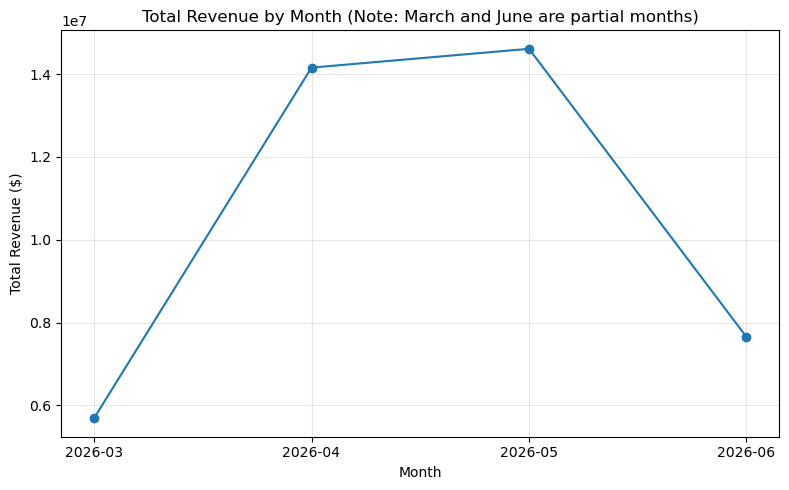

In [125]:
# Note: March and June are partial months in this dataset (data starts 19 March
# and ends 17 June), which explains the lower revenue at both edges of the chart —
# this is flagged directly in the chart title rather than left as a hidden caveat.
plt.figure(figsize=(8, 5))
plt.plot(monthly_revenue["activity_month"], monthly_revenue["total_revenue"], marker="o")
plt.title("Total Revenue by Month (Note: March and June are partial months)")
plt.xlabel("Month")
plt.ylabel("Total Revenue ($)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Business insight:** monthly revenue rose sharply from March to April, held roughly steady into May, then fell in June. Since March and June are partial calendar months in this dataset (data starts 19 March and ends 17 June), this rise and fall at the edges is explained by partial data coverage, not by a genuine change in customer demand — April and May are the only two full calendar months and are the fairest basis for comparison.

### Chart 2: Cohort spending heatmap

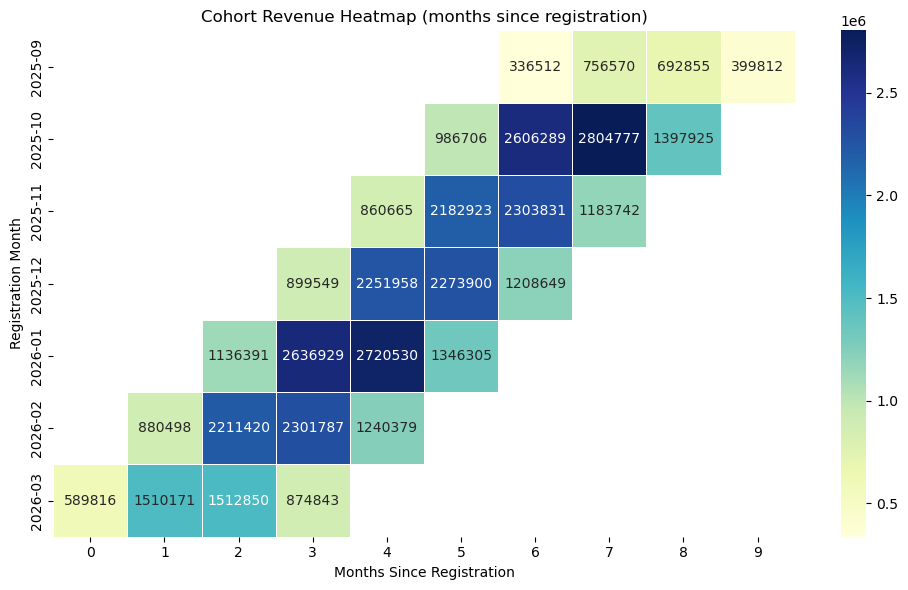

In [126]:
import seaborn as sns

cohort_pandas = cohort_table.orderBy("registration_month").toPandas()
cohort_pandas = cohort_pandas.set_index("registration_month")
cohort_pandas.columns = [int(c) for c in cohort_pandas.columns]
cohort_pandas = cohort_pandas.sort_index(axis=1)

plt.figure(figsize=(10, 6))
sns.heatmap(cohort_pandas, annot=True, fmt=".0f", cmap="YlGnBu", linewidths=0.5)
plt.title("Cohort Revenue Heatmap (months since registration)")
plt.xlabel("Months Since Registration")
plt.ylabel("Registration Month")
plt.tight_layout()
plt.show()

**Business insight:** the heatmap's diagonal band of blank cells makes the dataset's four-month observation window immediately visible — a pattern that is far less obvious from the underlying numeric table alone. This is a case where visualisation surfaces a structural data limitation, not just a business trend (see the note under Step 6 above).

### Chart 3: Top 10 products by revenue

In [127]:
# Computed from transactions_clean (item-level, exploded) joined with products
# for human-readable names — this is exactly the use case transactions_clean
# was kept around for (item-level analysis, not transaction-level totals)
top_products = transactions_clean.groupBy("product_id").agg(
    spark_sum("line_subtotal").alias("product_revenue")
).join(products_df.select("product_id", "name"), on="product_id", how="inner") \
 .orderBy(col("product_revenue").desc()) \
 .limit(10) \
 .toPandas()

top_products

,product_id,product_revenue,name
0,prod_00724,82913.04,Open-Source User-Facing Matrix
1,prod_00154,80210.25,Switchable Hybrid Focus Group
2,prod_00592,79587.36,Proactive Scalable Policy
3,prod_00967,79096.05,Streamlined 24Hour Complexity
4,prod_00074,76883.04,Configurable Disintermediate Success
5,prod_00585,76847.82,Devolved Web-Enabled Capability
6,prod_00306,75462.45,Devolved Multi-Tasking Hierarchy
7,prod_00892,74480.00,Function-Based Content-Based Budgetary Management
8,prod_00923,74469.12,Programmable Impactful Help-Desk
9,prod_01333,74372.50,Adaptive Multimedia Strategy


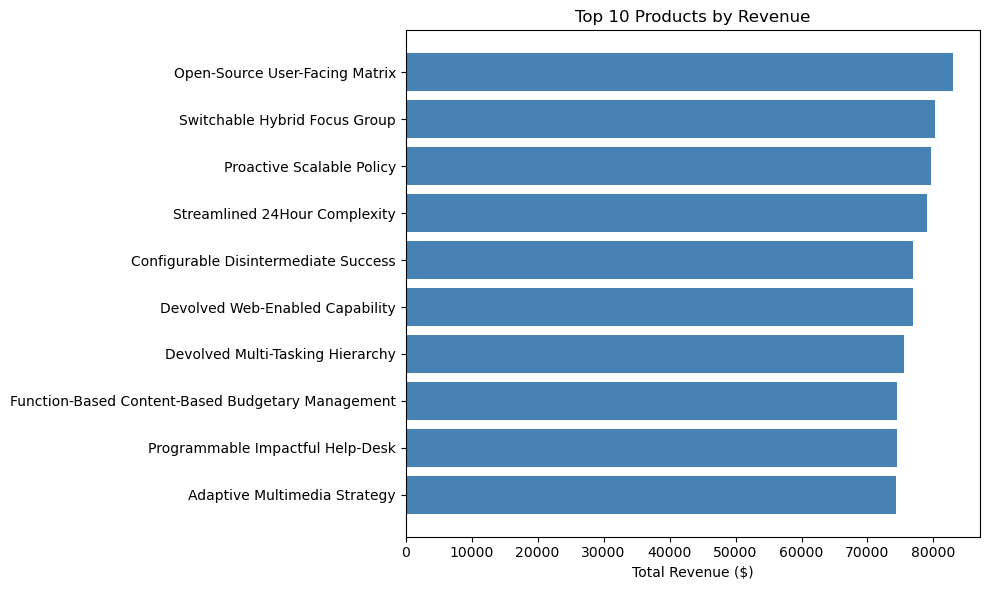

In [128]:
# invert_yaxis() puts the highest-revenue product at the top of the chart,
# matching how a "top 10" ranking is naturally read
plt.figure(figsize=(10, 6))
plt.barh(top_products["name"], top_products["product_revenue"], color="steelblue")
plt.xlabel("Total Revenue ($)")
plt.title("Top 10 Products by Revenue")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Business insight:** the top 10 products span a narrow revenue band (\$74,372.50 to \$82,913.04, roughly a 10% spread), indicating a catalogue without a single dominant bestseller driving sales — revenue here is broad-based rather than concentrated in one or two hit products.

### Chart 4: CLV segment distribution

In [129]:
segment_summary = clv_segmented.groupBy("segment").agg(
    spark_count("user_id").alias("num_users"),
    spark_avg("total_spend").alias("avg_spend")
).toPandas()

# Force the High -> Mid -> Low business ordering instead of alphabetical
segment_order = ["High Value", "Mid Value", "Low Value"]
segment_summary["segment"] = segment_summary["segment"].astype("category")
segment_summary["segment"] = segment_summary["segment"].cat.set_categories(segment_order)
segment_summary = segment_summary.sort_values("segment")

segment_summary

,segment,num_users,avg_spend
0,High Value,400,29566.223250
1,Mid Value,600,23073.496067
2,Low Value,1000,16437.995520


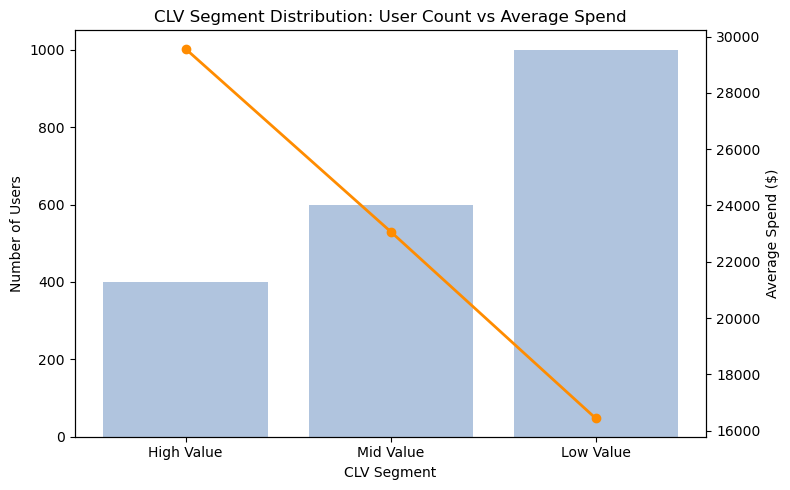

In [130]:
# Dual-axis chart: bars (user count) and line (avg spend) need separate
# y-axes since they're on very different scales (hundreds vs tens of thousands)
fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.bar(segment_summary["segment"], segment_summary["num_users"], color="lightsteelblue", label="Number of Users")
ax1.set_ylabel("Number of Users")
ax1.set_xlabel("CLV Segment")

ax2 = ax1.twinx()
ax2.plot(segment_summary["segment"], segment_summary["avg_spend"], color="darkorange", marker="o", linewidth=2, label="Avg Spend ($)")
ax2.set_ylabel("Average Spend ($)")

plt.title("CLV Segment Distribution: User Count vs Average Spend")
fig.tight_layout()
plt.show()

**Business insight:** the bars (population) and the line (average spend) move in opposite directions across the three segments — population grows from High to Low Value (400 -> 600 -> 1,000) while average spend falls (\$29,566 -> \$23,073 -> \$16,438). This confirms that customer value in this dataset is concentrated in a numerically smaller, higher-value minority of the user base, which is the standard justification for prioritising retention spend on the High Value segment specifically, rather than spreading it evenly across the whole customer base.